In [1]:
import sys
sys.path.append('..')
from VRT import VRT
from MORES import MORES
import numpy as np
from postprocessing import Mueller2sigma0VH
import matplotlib.pyplot as plt

mores = MORES()
mores.init_from_model_file("../Tsang1985Fig4.toml")
vrt = VRT(mores)
vrt.Mue_volume_nosurface((30, 180, 30, 0))

array([[ 1.07153225e-02,  1.71433422e-04, -9.42173014e-10,
        -1.87746850e-11],
       [ 1.71433422e-04,  1.09659891e-02,  9.54784658e-10,
         7.48168358e-12],
       [-1.88410323e-09,  1.92030511e-09, -1.06868963e-02,
        -2.89177289e-04],
       [ 3.69646354e-11, -1.44988011e-11,  2.89177289e-04,
        -1.03440294e-02]])

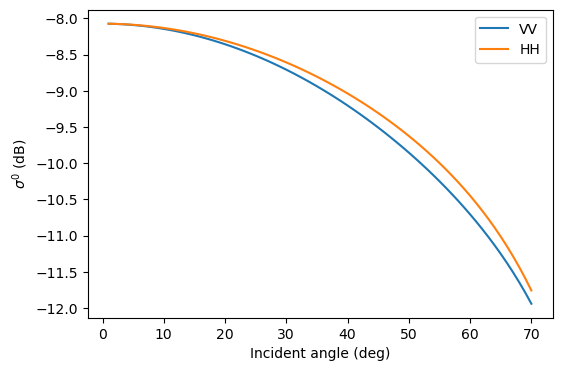

In [2]:
theta_is = np.linspace(1, 70, 70)
Num = len(theta_is)
sigma0_VVs = np.zeros(Num)
sigma0_HHs = np.zeros(Num)
for i in range(Num):
    theta_i = theta_is[i]
    Mue = vrt.Mue_volume_nosurface((theta_i, 180, theta_i, 0))
    sigma_VV, _, _, sigma_HH = Mueller2sigma0VH(Mue)
    sigma0_VVs[i] = sigma_VV
    sigma0_HHs[i] = sigma_HH

sigma0_VV_dB = 10*np.log10(sigma0_VVs)
sigma0_HH_dB = 10*np.log10(sigma0_HHs)
# sigma0_VV_dB = (sigma0_VVs.real)
# sigma0_HH_dB = (sigma0_HHs.real)
plt.figure(figsize=(6, 4))
plt.plot(theta_is, sigma0_VV_dB, label='VV')
plt.plot(theta_is, sigma0_HH_dB, label='HH')
# plt.ylim(-45, -15)
# plt.ylim(-35, -5)
plt.xlabel('Incident angle (deg)')
plt.ylabel('$\sigma^0$ (dB)')
plt.legend()
plt.show()

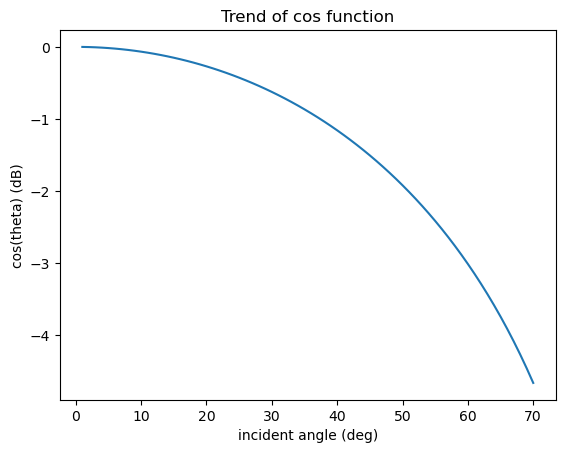

In [11]:
theta_is = np.linspace(1, 70, 70)
Num = len(theta_is)
sigma0_coss = np.zeros(Num)
for i in range(Num):
    sigma0_coss[i] = 10*np.log10(np.cos(np.deg2rad(theta_is[i])))

plt.figure()
plt.plot(theta_is, sigma0_coss)
plt.xlabel('incident angle (deg)')
plt.ylabel('cos(theta) (dB)')
plt.title('Trend of cos function')
plt.show()

In [4]:
10*np.log10(np.cos(np.deg2rad(70)))

-4.6594831535448265

In [8]:
np.sign(0)

0